Saving archive (1).zip to archive (1).zip
First 5 rows:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


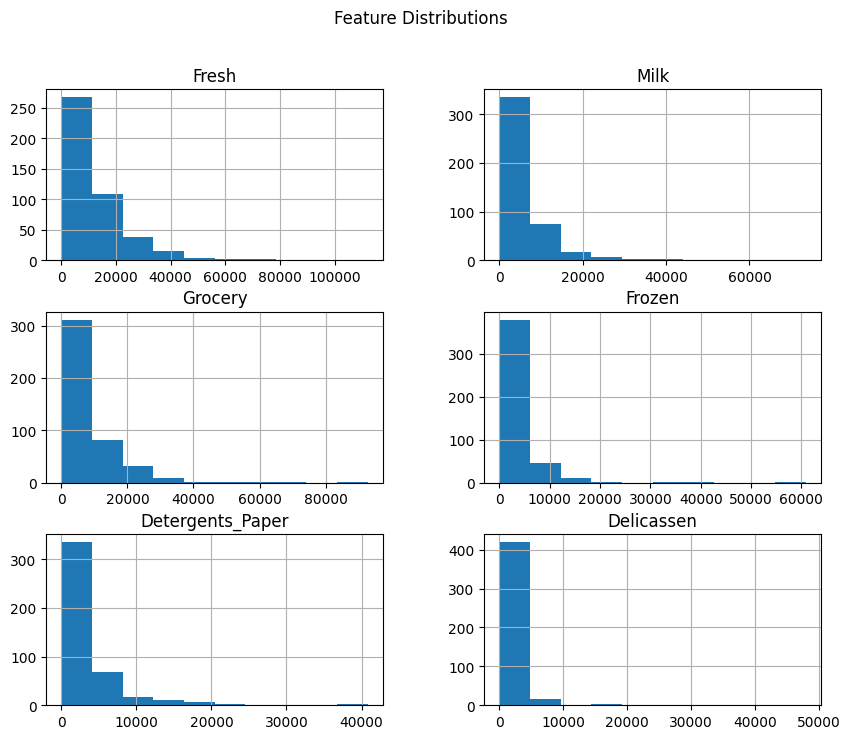

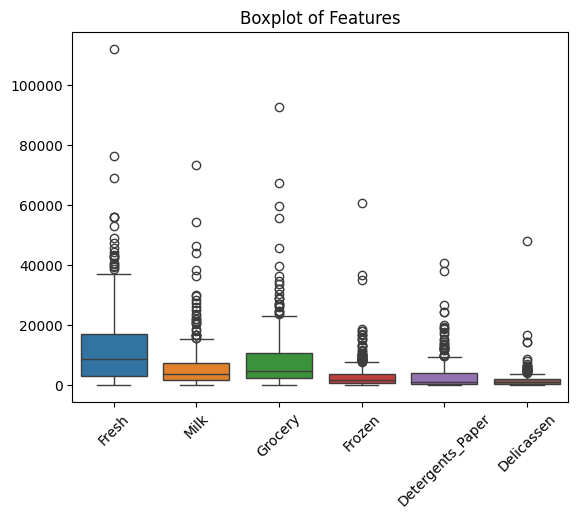

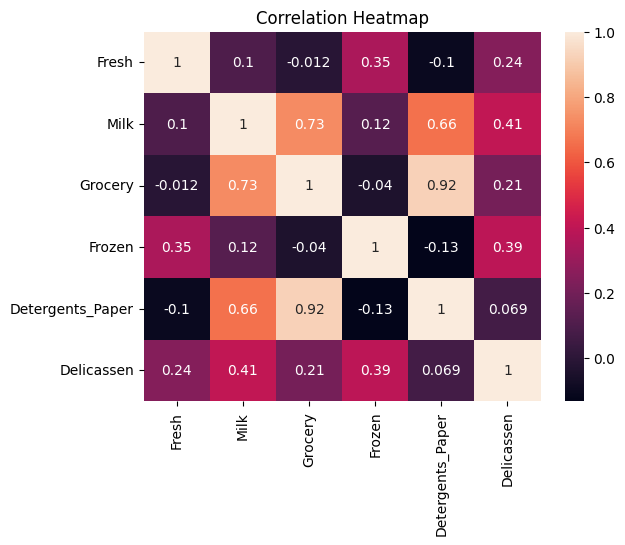

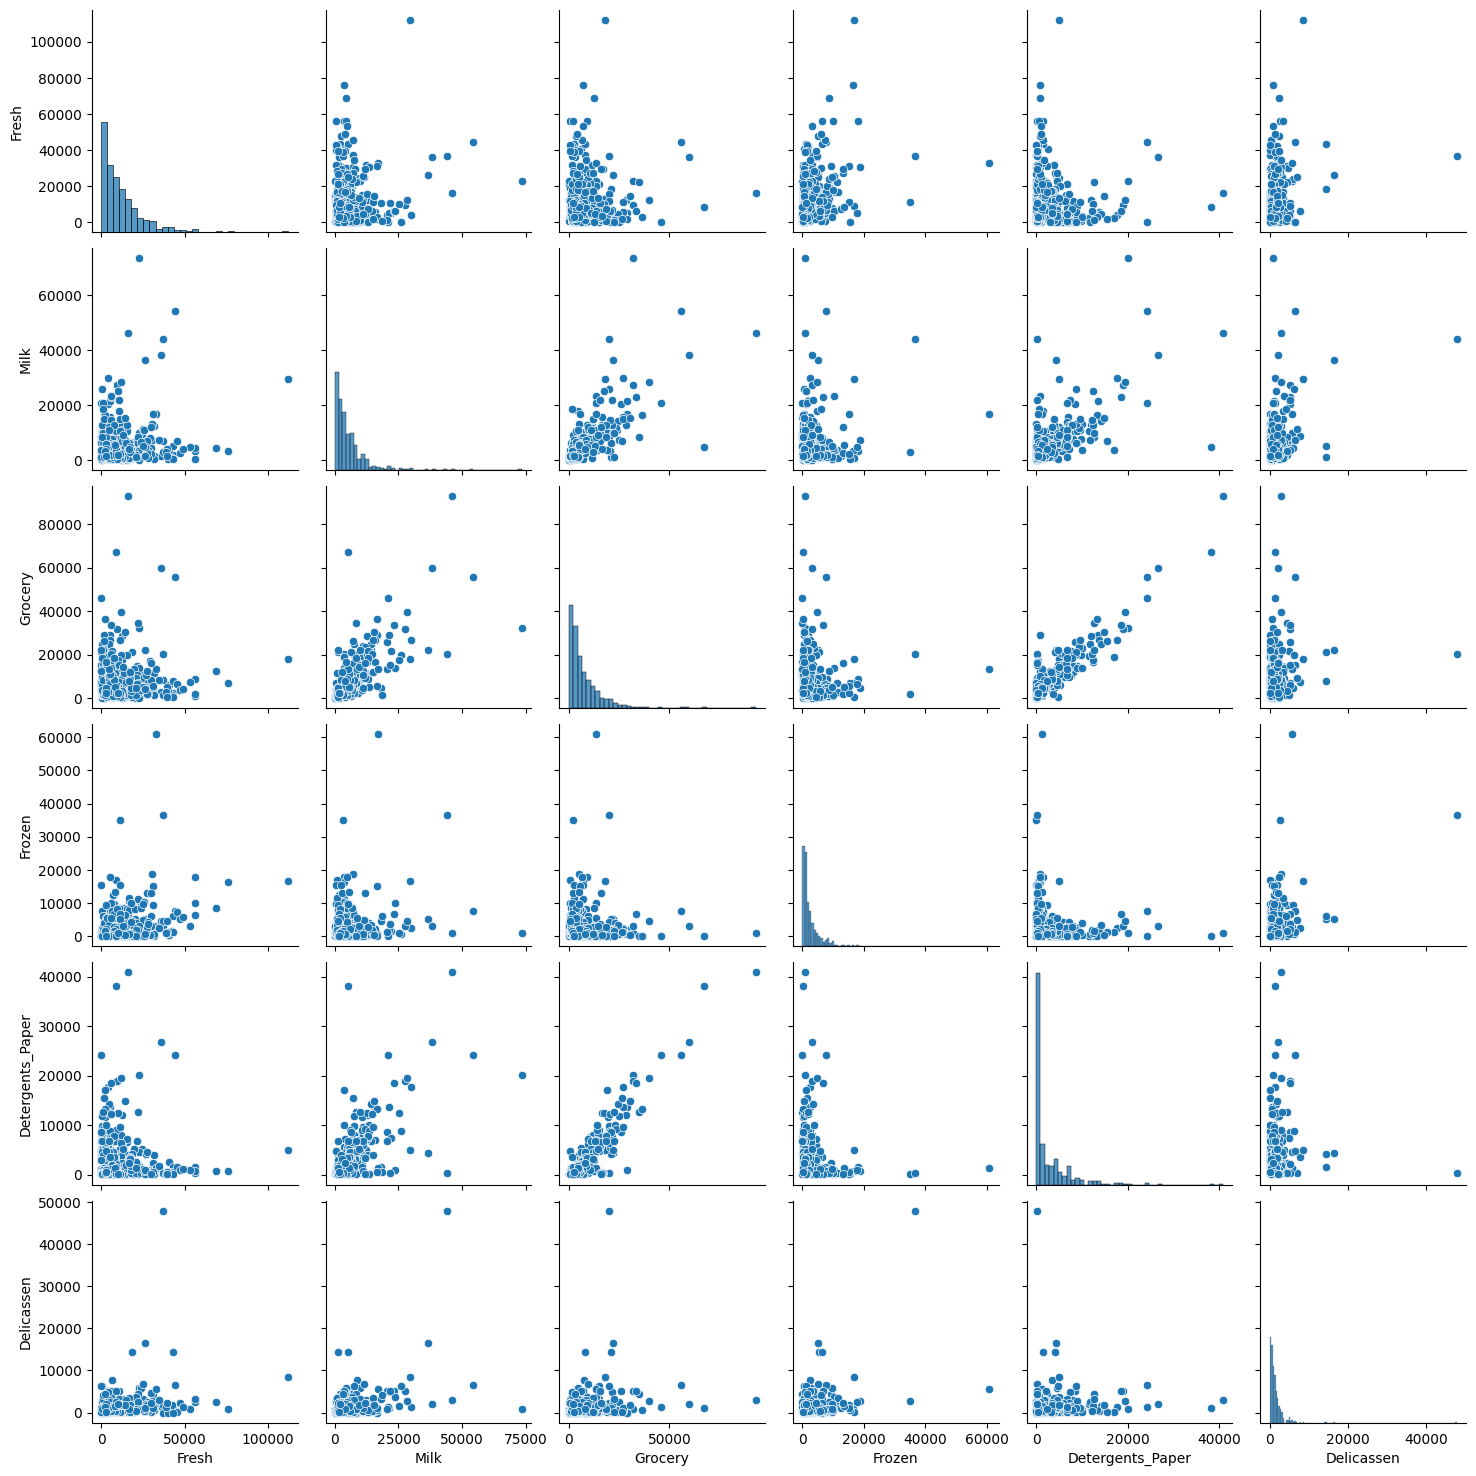

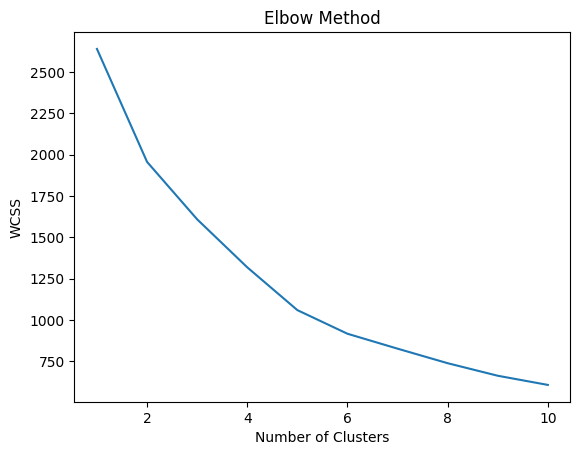


Clustered Data:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  Cluster  
0        1338        0  
1        1776        3  
2        7844        3  
3        1788        0  
4        5185        2  


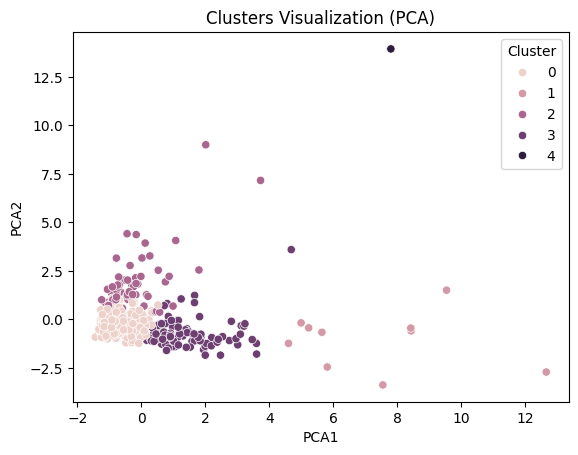


Cluster Summary:
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
0        1.137037  2.518519   9092.155556   2967.759259   3807.411111   
1        2.000000  2.500000  15964.900000  34708.500000  48536.900000   
2        1.126984  2.682540  32957.984127   4997.349206   5884.761905   
3        1.906250  2.520833   5754.166667  10866.604167  16607.104167   
4        1.000000  3.000000  36847.000000  43950.000000  20170.000000   

               Frozen  Detergents_Paper    Delicassen      PCA1       PCA2  
Cluster                                                                     
0         2271.759259        989.814815    978.962963 -0.746463  -0.186869  
1         3054.600000      24875.200000   2942.800000  7.286742  -1.059853  
2         8422.841270        954.603175   2462.968254 -0.196717   1.844324  
3         1464.125000       7202.875000   1813.385417  1.388258  -0.719670  
4       

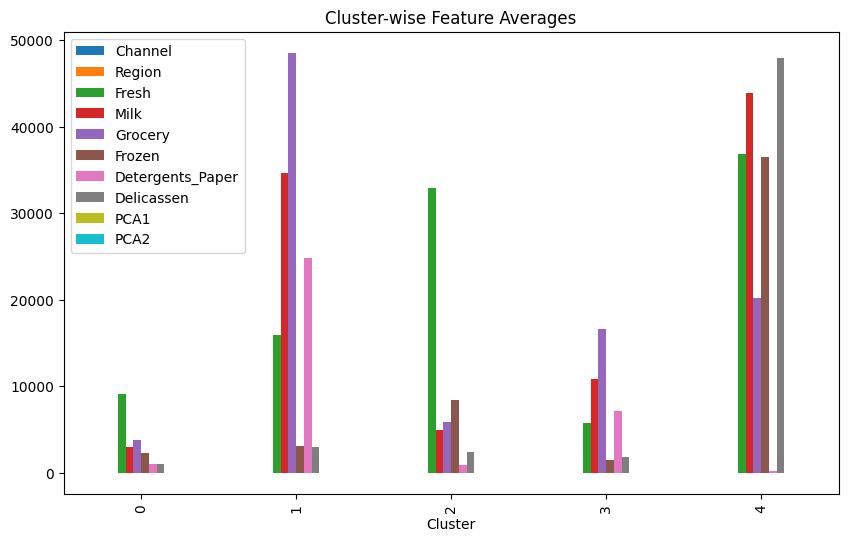

In [2]:
# =========================
# STEP 1: Install libraries
# =========================
!pip install seaborn scikit-learn

# =========================
# STEP 2: Import libraries
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# =========================
# STEP 3: Upload dataset
# =========================
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# =========================
# STEP 4: Load dataset
# =========================
df = pd.read_csv(file_name)

print("First 5 rows:")
print(df.head())

# =========================
# STEP 5: Drop non-numeric columns
# =========================
# Usually 'Channel' and 'Region' can be kept or dropped
df_clean = df.drop(['Channel', 'Region'], axis=1)

# =========================
# STEP 6: Basic Visualizations
# =========================

# Histograms
df_clean.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

# Boxplots (detect outliers)
plt.figure()
sns.boxplot(data=df_clean)
plt.title("Boxplot of Features")
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap
plt.figure()
sns.heatmap(df_clean.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Pairplot (important)
sns.pairplot(df_clean)
plt.show()

# =========================
# STEP 7: Standardization
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# =========================
# STEP 8: Elbow Method
# =========================
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# =========================
# STEP 9: Apply K-Means
# =========================
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("\nClustered Data:")
print(df.head())

# =========================
# STEP 10: PCA (2D Visualization)
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure()
sns.scatterplot(x=df['PCA1'], y=df['PCA2'], hue=df['Cluster'])
plt.title("Clusters Visualization (PCA)")
plt.show()

# =========================
# STEP 11: Cluster-wise Analysis
# =========================
cluster_summary = df.groupby('Cluster').mean()
print("\nCluster Summary:")
print(cluster_summary)

# Barplot for clusters
cluster_summary.plot(kind='bar', figsize=(10,6))
plt.title("Cluster-wise Feature Averages")
plt.show()